In [ ]:
# Data manipulation and analysis libraries
import pandas as pd  # For data manipulation and analysis
import numpy as np   # For numerical operations and arrays

# Image processing libraries
from PIL import Image          # Python Imaging Library for opening/manipulating images
import matplotlib.pyplot as plt # For plotting and visualization

from sklearn.model_selection import train_test_split, KFold  # For splitting datasets
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report # For model evaluation
import seaborn as sns         # Statistical data visualization


# PyTorch deep learning framework and its components
import torch                    # Main PyTorch library
import torch.nn as nn          # Neural network modules
import torch.nn.functional as F # Neural network functions
import torch.optim as optim    # Optimization algorithms
from torch.optim import lr_scheduler        # Learning rate scheduling
from torchvision import models             # Pre-trained models
from torchvision.datasets import ImageFolder # Dataset class for images
import torchsummary                        # For model architecture visualization

# PyTorch data handling utilities
from torch.utils.data.sampler import SubsetRandomSampler # For random sampling
from torch.utils.data import Dataset      # Base dataset class
from torch.utils.data import DataLoader   # For batch loading

# Data augmentation and transformation utilities
import torchvision                        # Computer vision library
from torchvision import datasets, models, transforms, utils # Vision utilities
from torchvision.transforms import v2     # Latest transform operations

In [ ]:
pip install kaggle

In [ ]:
# Define the dataset slug (from the Kaggle URL)
dataset_slug = 'hosseinbadrnezhad/human-faces-dataset-male-female-classification'

# Define the destination directory
destination_dir = 'data'

# Create the destination directory if it doesn't exist
import os
if not os.path.exists(destination_dir):
    os.makedirs(destination_dir)

# Download and unzip the dataset using Kaggle CLI
# The -p flag specifies the path where to download the dataset
# The --unzip flag extracts the content of the zip file after downloading
!kaggle datasets download -d {dataset_slug} -p {destination_dir} --unzip

print(f"Dataset downloaded and unzipped to '{destination_dir}/'")

Dataset URL: https://www.kaggle.com/datasets/hosseinbadrnezhad/human-faces-dataset-male-female-classification
License(s): apache-2.0
100% 1.05G/1.05G [00:28<00:00, 39.3MB/s]

Dataset downloaded and unzipped to 'data/'


In [ ]:
# Initialize empty DataFrame with columns for image path, label and class ID
df = pd.DataFrame({"path":[],"label":[], "class_id":[]})
# Set path to training data directory
train_path = 'train'

# Define list of class labels for gender classification
label_list = [
    'men',   # class_id = 0
    'women', # class_id = 1
]

In [ ]:
import os

# Populate the DataFrame
for label in label_list:
    class_id = label_list.index(label)
    path = os.path.join(destination_dir, label)
    for img_file in os.listdir(path):
        df.loc[len(df)] = [os.path.join(path, img_file), label, class_id]

print(f"DataFrame populated with {len(df)} entries.")


DataFrame populated with 2000 entries.


In [ ]:
print(df.head())

                      path label  class_id
0  data/men/image_1647.jpg   men         0
1   data/men/image_492.jpg   men         0
2  data/men/image_1841.jpg   men         0
3  data/men/image_1104.jpg   men         0
4  data/men/image_1811.jpg   men         0


In [ ]:
print(df.tail())

                           path  label  class_id
1995  data/women/image_1466.jpg  women         1
1996  data/women/image_1522.jpg  women         1
1997  data/women/image_1012.jpg  women         1
1998   data/women/image_761.jpg  women         1
1999   data/women/image_293.jpg  women         1


In [ ]:
# Convert DataFrame columns to appropriate data types
df[["path"]] = df[["path"]].astype(str)     # Path as string
df[["label"]] = df[["label"]].astype(str)   # Label as string
df[["class_id"]] = df[["class_id"]].astype(int) # Class ID as integer

In [ ]:
# Split the DataFrame into training and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['class_id'])

print(f"Training data shape: {train_df.shape}")
print(f"Validation data shape: {val_df.shape}")

print("\nTraining set class distribution:")
print(train_df['label'].value_counts())

print("\nValidation set class distribution:")
print(val_df['label'].value_counts())


Training data shape: (1600, 3)
Validation data shape: (400, 3)

Training set class distribution:
label
women    1018
men       582
Name: count, dtype: int64

Validation set class distribution:
label
women    255
men      145
Name: count, dtype: int64


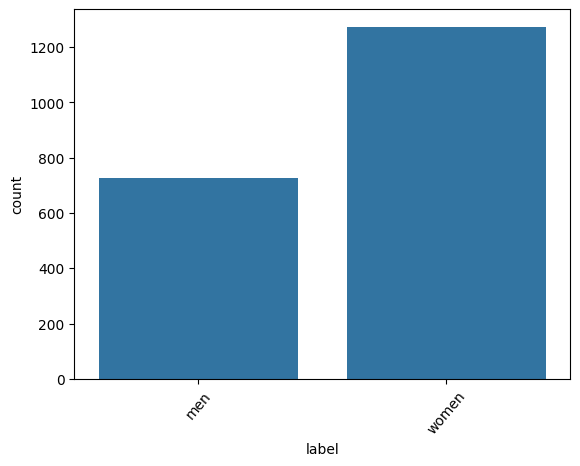

In [ ]:
sns.countplot(x = df["label"])
plt.xticks(rotation = 50);

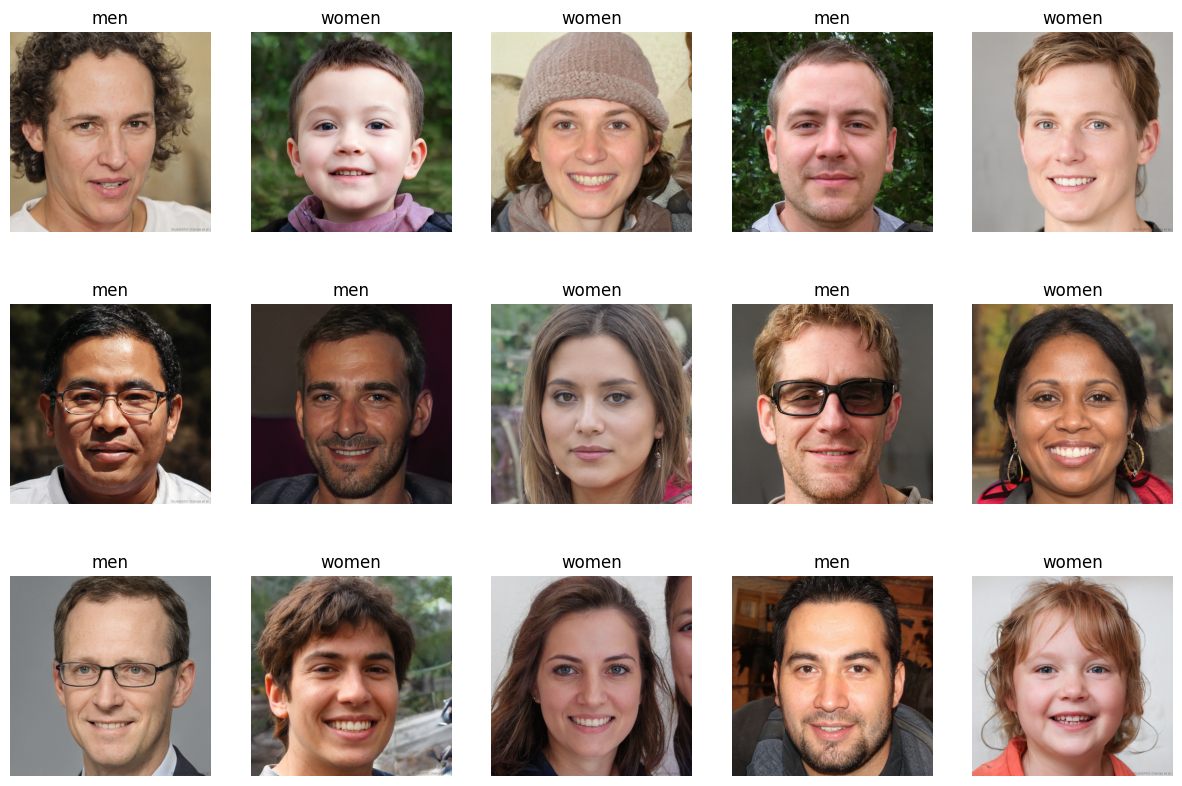

In [ ]:
# Number of random images to display
show_imgs = 15

# Generate random indices to select images from the dataset
idx = np.random.randint(0, len(df),size=show_imgs)

# Create a figure with subplots arranged in 3 rows and 5 columns
fig, axes = plt.subplots(show_imgs//5, 5, figsize=(15,10))

# Flatten the 2D array of axes into 1D for easier iteration
axes = axes.flatten()

# Iterate through each subplot axis
for i, ax in enumerate(axes):
    # Get the full file path for the randomly selected image
    full_path = df.loc[idx[i]]['path']

    # Display the image in the current subplot
    ax.imshow(plt.imread(full_path))

    # Set the subplot title to show the gender label
    ax.set_title(df.loc[idx[i]]['label'])

    # Remove axis ticks and labels for cleaner visualization
    ax.set_axis_off()

In [ ]:
X_train = train_df['path']
y_train = train_df['class_id']
X_val   = val_df['path']
y_val   = val_df['class_id']

In [ ]:
import torch
import torchvision.transforms.v2 as v2

train_transforms = v2.Compose([
    v2.Resize((224, 224)),

    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(15),

    v2.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    v2.RandomResizedCrop(224, scale=(0.8, 1.0)),

    v2.GaussianBlur(kernel_size=3),

    v2.ToImage(),              # converts PIL/array → tensor image
    v2.ToDtype(torch.float32, scale=True),  # scales to [0,1]

    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
test_transforms = v2.Compose([
    v2.Resize((224, 224)),

    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),

    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
class GenderDataset(torch.utils.data.Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1. Get image path
        img_path = self.image_paths.iloc[idx]

        # 2. Load image from disk
        img = Image.open(img_path).convert("RGB")

        # 3. Get label
        label = self.labels.iloc[idx]

        # 4. Apply transforms (augmentation + preprocessing)
        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
train_dataset = GenderDataset(X_train, y_train, transform=train_transforms)
val_dataset   = GenderDataset(X_val, y_val, transform=test_transforms)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GenderCNN(nn.Module):
    def __init__(self):
        super(GenderCNN, self).__init__()

        # -------- Convolutional Block 1 --------
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        # -------- Convolutional Block 2 --------
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        # -------- Convolutional Block 3 --------
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        # Pooling
        self.pool = nn.MaxPool2d(2, 2)

        # -------- Fully Connected --------
        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        # Block 1: Conv → BN → ReLU → Pool
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 224 → 112

        # Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 112 → 56

        # Block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 56 → 28

        # Flatten
        x = x.view(x.size(0), -1)

        # Fully connected + Dropout
        x = self.dropout(F.relu(self.fc1(x)))

        # Output
        x = self.fc2(x)

        return x

In [ ]:
model = GenderCNN()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
nn.BatchNorm2d(32)

BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:




criterion = nn.CrossEntropyLoss()

In [ ]:
for epoch in range(10):
    model.train()
    current_train_loss = 0.0 # Initialize training loss for the current epoch
    num_train_batches = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        current_train_loss += loss.item() # Accumulate loss
        num_train_batches += 1

    train_loss = current_train_loss / num_train_batches # Calculate average train loss for the epoch
    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}")

Epoch 1, Train Loss: 0.3747
Epoch 2, Train Loss: 0.3702
Epoch 3, Train Loss: 0.3469
Epoch 4, Train Loss: 0.3524
Epoch 5, Train Loss: 0.3617
Epoch 6, Train Loss: 0.3139
Epoch 7, Train Loss: 0.3264
Epoch 8, Train Loss: 0.3552
Epoch 9, Train Loss: 0.3065
Epoch 10, Train Loss: 0.2796


In [ ]:
model.eval()
val_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total

print(f"Epoch {epoch+1}")
print(f"Train Loss: {train_loss:.4f}")
print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%\n")

Epoch 10
Train Loss: 0.2796
Val Loss: 3.5318, Val Acc: 88.75%



In [ ]:
all_labels = []
all_preds = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

[[118  27]
 [ 18 237]]


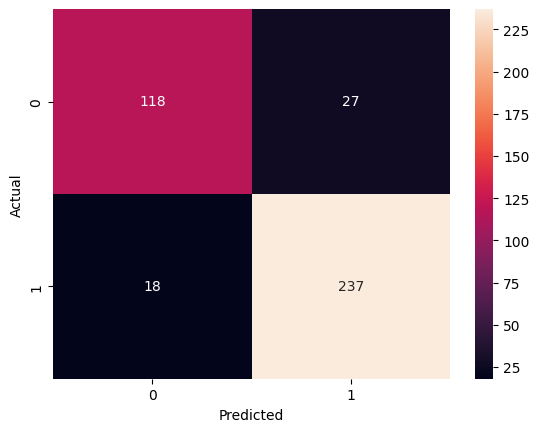

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(all_labels, all_preds)
print(cm)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#save model




In [ ]:
torch.save(model.state_dict(), 'gender_cnn_model_final.pth')
print("Model saved to gender_cnn_model_final.pth")

Model saved to gender_cnn_model.pth


In [ ]:
#real test
l=["im1","im2"]

In [ ]:
# Example: Populating 'l' with actual image paths for demonstration
# You can replace these with the actual paths of the images you want to test
l = [
    "/content/femme9.avif",
    "/content/female-health.jpg",
    "/content/femme.jpg",
    "/content/femme2.jpg",
    "/content/femme3.jpg",
    "/content/femme4.jpg",
    "/content/femme5.jpg",
    "/content/femme6.jpg",
    "/content/femme7.jpg",
    "/content/femme8.jpg",
    "/content/male.jpg",
    "/content/male2.jpg",
    "/content/male3.jpg",
    "/content/male4.avif",
    "/content/male5.jpg"
]

In [ ]:
class PredictionDataset(torch.utils.data.Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths.iloc[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, img_path # Return image and its path

# Convert the list 'l' to a pandas Series to be compatible with .iloc[idx]
prediction_paths = pd.Series(l)

# Create the prediction dataset and dataloader
prediction_dataset = PredictionDataset(prediction_paths, transform=test_transforms);
prediction_loader = DataLoader(prediction_dataset, batch_size=1, shuffle=False)

print(f"Prepared {len(prediction_dataset)} images for prediction.")

Prepared 15 images for prediction.


In [ ]:
model.eval() # Set the model to evaluation mode
predictions = []
actual_paths = []

with torch.no_grad(): # Disable gradient calculations
    for images, paths in prediction_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        predictions.append(predicted.item())
        actual_paths.append(paths[0]) # paths is a tuple, so take the first element

# Map class IDs back to labels
predicted_labels = [label_list[pred_id] for pred_id in predictions]

print("--- Predictions ---")
for i, path in enumerate(actual_paths):
    print(f"Image: {path}, Predicted Gender: {predicted_labels[i]}")

--- Predictions ---
Image: /content/femme9.avif, Predicted Gender: men
Image: /content/female-health.jpg, Predicted Gender: men
Image: /content/femme.jpg, Predicted Gender: men
Image: /content/femme2.jpg, Predicted Gender: women
Image: /content/femme3.jpg, Predicted Gender: women
Image: /content/femme4.jpg, Predicted Gender: women
Image: /content/femme5.jpg, Predicted Gender: women
Image: /content/femme6.jpg, Predicted Gender: women
Image: /content/femme7.jpg, Predicted Gender: men
Image: /content/femme8.jpg, Predicted Gender: men
Image: /content/male.jpg, Predicted Gender: women
Image: /content/male2.jpg, Predicted Gender: women
Image: /content/male3.jpg, Predicted Gender: women
Image: /content/male4.avif, Predicted Gender: women
Image: /content/male5.jpg, Predicted Gender: women
